# Dataquest 2023 Preliminary: basic EDA of the IKN rainfall dataset

In [83]:
import pandas as pd
import numpy as np
import datetime
import warnings

from matplotlib import dates as mdates
from matplotlib import pyplot as plt
import seaborn as sns
import re

from sklearn import metrics
from math import sqrt

warnings.simplefilter('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 300

DATA_DIR = "../data"

train_df = pd.read_csv(f"{DATA_DIR}/train.csv")

In [84]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 341880 entries, 0 to 341879
Data columns (total 20 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   datetime      341880 non-null  int64 
 1   datetime_iso  341880 non-null  object
 2   time-zone     341880 non-null  int64 
 3   temp          341880 non-null  object
 4   visibility    51112 non-null   object
 5   d_point       341880 non-null  object
 6   feels         341880 non-null  object
 7   min_temp      341880 non-null  object
 8   max_temp      341880 non-null  object
 9   prssr         341880 non-null  object
 10  sea_level     192964 non-null  object
 11  grnd_level    192919 non-null  object
 12  hum           341880 non-null  object
 13  wind_spd      341880 non-null  object
 14  wind_deg      341880 non-null  object
 15  rain_1h       341880 non-null  object
 16  rain_3h       192329 non-null  object
 17  snow_1h       192696 non-null  object
 18  snow_3h       192699 non

In [81]:
train_df.head(5)

,datetime,datetime_iso,time-zone,temp,visibility,d_point,feels,min_temp,max_temp,prssr,sea_level,grnd_level,hum,wind_spd,wind_deg,rain_1h,rain_3h,snow_1h,snow_3h,clouds
0,283996800,1979-01-01 00:00:00+00:00,28800,24.75 Celcius,NaN,23.89 C,25.76 C,24.28,25.22°C,1012,undetermined,NaN,95,0.82,320.0 °,zero,0,NaN,NaN,100
1,284000400,1979-01-01 01:00:00+00:00,28800,24.58 C,NaN,23.73 C,25.57 C,23.99 C,25.26 C,1012,NaN,NaN,95,0.96 m/s,338.0°,0,0,0,0,100
2,284004000,1979-01-01 02:00:00+00:00,28800,26.6 Celcius,unidentified,24.06 C,26.6 C,26.1 C,27.39,1012,NaN,undetermined,86,1.22 m/s,339.0°,0,volume:zero,NaN,NaN,99
3,284007600,1979-01-01 03:00:00+00:00,28800,27.31 Celcius,NaN,24.37 C,30.9 C,26.59,28.36 C,1012,NaN,undetermined,84,1.08 m/s,342,0.13,nol,0,NaN,94
4,284011200,1979-01-01 04:00:00+00:00,28800,27.41,NaN,25.05 C,31.54 C,26.58 C,28.31 °C,1011,NaN,undetermined,87,0.86,336.0°,0.34,nol,NaN,0,100


Beberapa kolom belum dalam format yang diinginkan, seperti pada kolom temp, kita perlu menjadikan float dan membuang keterangan satuan derajatnya

In [34]:
def clean_cols(df, is_train=True):
    df['datetime'] = pd.to_datetime(df['datetime'], unit='s')

    # function to clean unit
    def clean_unit(x):
        temp_pattern = r'-?\d+(\.\d+)?'
        regex = re.search(temp_pattern, str(x))
        return float(regex.group(0)) if regex else np.nan

    # clean unit
    df['temp'] = df['temp'].apply(clean_unit)
    df['d_point'] = df['d_point'].apply(clean_unit)
    df['feels'] = df['feels'].apply(clean_unit)
    df['min_temp'] = df['min_temp'].apply(clean_unit)
    df['max_temp'] = df['max_temp'].apply(clean_unit)
    df['prssr'] = df['prssr'].apply(clean_unit)
    df['hum'] = df['hum'].apply(clean_unit) / 100
    df['wind_spd'] = df['wind_spd'].apply(clean_unit)
    df['wind_deg'] = df['wind_deg'].apply(clean_unit)
    df['clouds'] = df['clouds'].apply(clean_unit) / 100

    df.loc[df['hum'] > 1, 'hum'] = 1

    # clean rain_1h
    if is_train:
        df.loc[df['rain_1h'] == 'zero', 'rain_1h'] = 0
        df.loc[df['rain_1h'] == ' ', 'rain_1h'] = np.nan
        df.dropna(subset=['rain_1h'], inplace=True)
        df['rain_1h'] = df['rain_1h'].apply(clean_unit)
        df.loc[df['rain_1h'] < 0, 'rain_1h'] = 0

    # drop useless columns
    # beberapa karena hampir semuanya nan
    df.drop(['datetime_iso',
             'time-zone',
             'visibility',
             'sea_level',
             'grnd_level',
             'rain_3h',
             'snow_1h',
             'snow_3h'],
            axis=1, inplace=True)

    return df

train_df = clean_cols(train_df)
# test_df = clean_cols(test_df, is_train=False)
train_df.head()

,datetime,temp,d_point,feels,min_temp,max_temp,prssr,hum,wind_spd,wind_deg,rain_1h,clouds
0,1979-01-01 00:00:00,24.75,23.89,25.76,24.28,25.22,1012.0,0.95,0.82,320.0,0.00,1.00
1,1979-01-01 01:00:00,24.58,23.73,25.57,23.99,25.26,1012.0,0.95,0.96,338.0,0.00,1.00
2,1979-01-01 02:00:00,26.60,24.06,26.60,26.10,27.39,1012.0,0.86,1.22,339.0,0.00,0.99
3,1979-01-01 03:00:00,27.31,24.37,30.90,26.59,28.36,1012.0,0.84,1.08,342.0,0.13,0.94
4,1979-01-01 04:00:00,27.41,25.05,31.54,26.58,28.31,1011.0,0.87,0.86,336.0,0.34,1.00


## EDA

In [ ]:
# monthly data agg
monthly_data = train_df.set_index('datetime').resample('M').agg({
    'rain_1h': 'mean',   
    'temp' : 'mean'
})

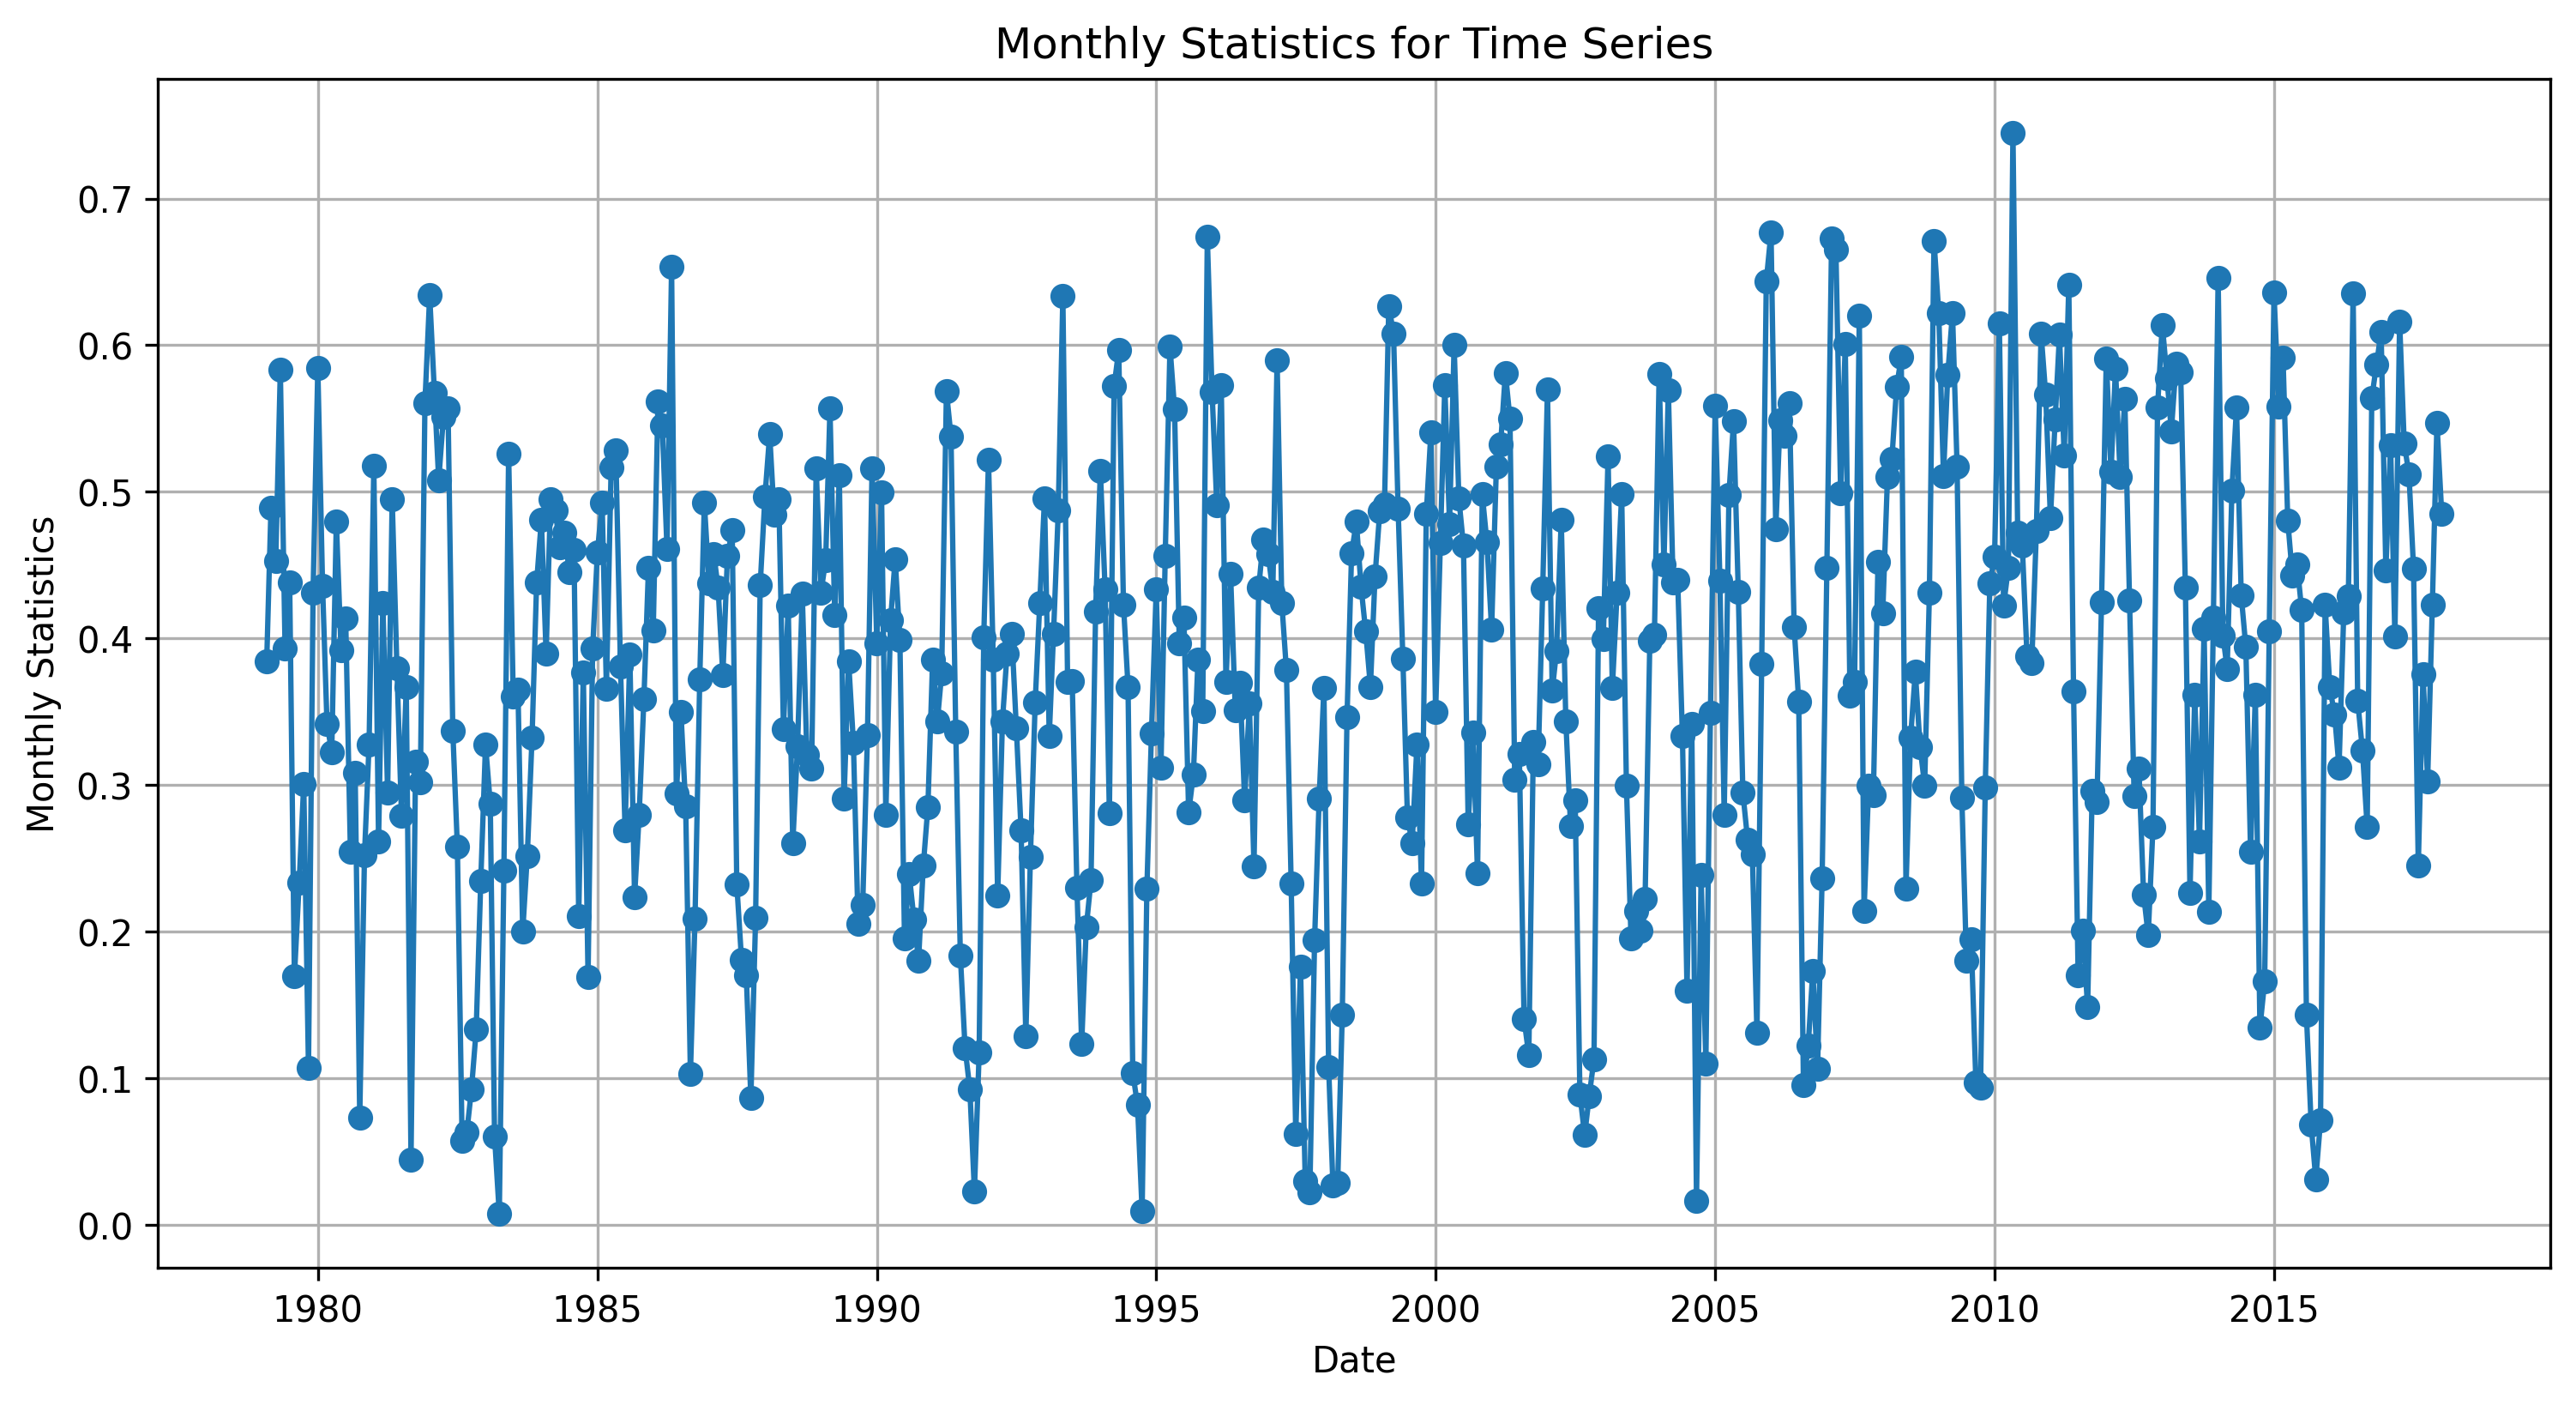

In [53]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_data.index, monthly_data['rain_1h'], marker='o', linestyle='-')
plt.xlabel('Date')
plt.ylabel('Monthly Statistics')
plt.title('Monthly Statistics rain_1h')
plt.grid(True)
plt.show()

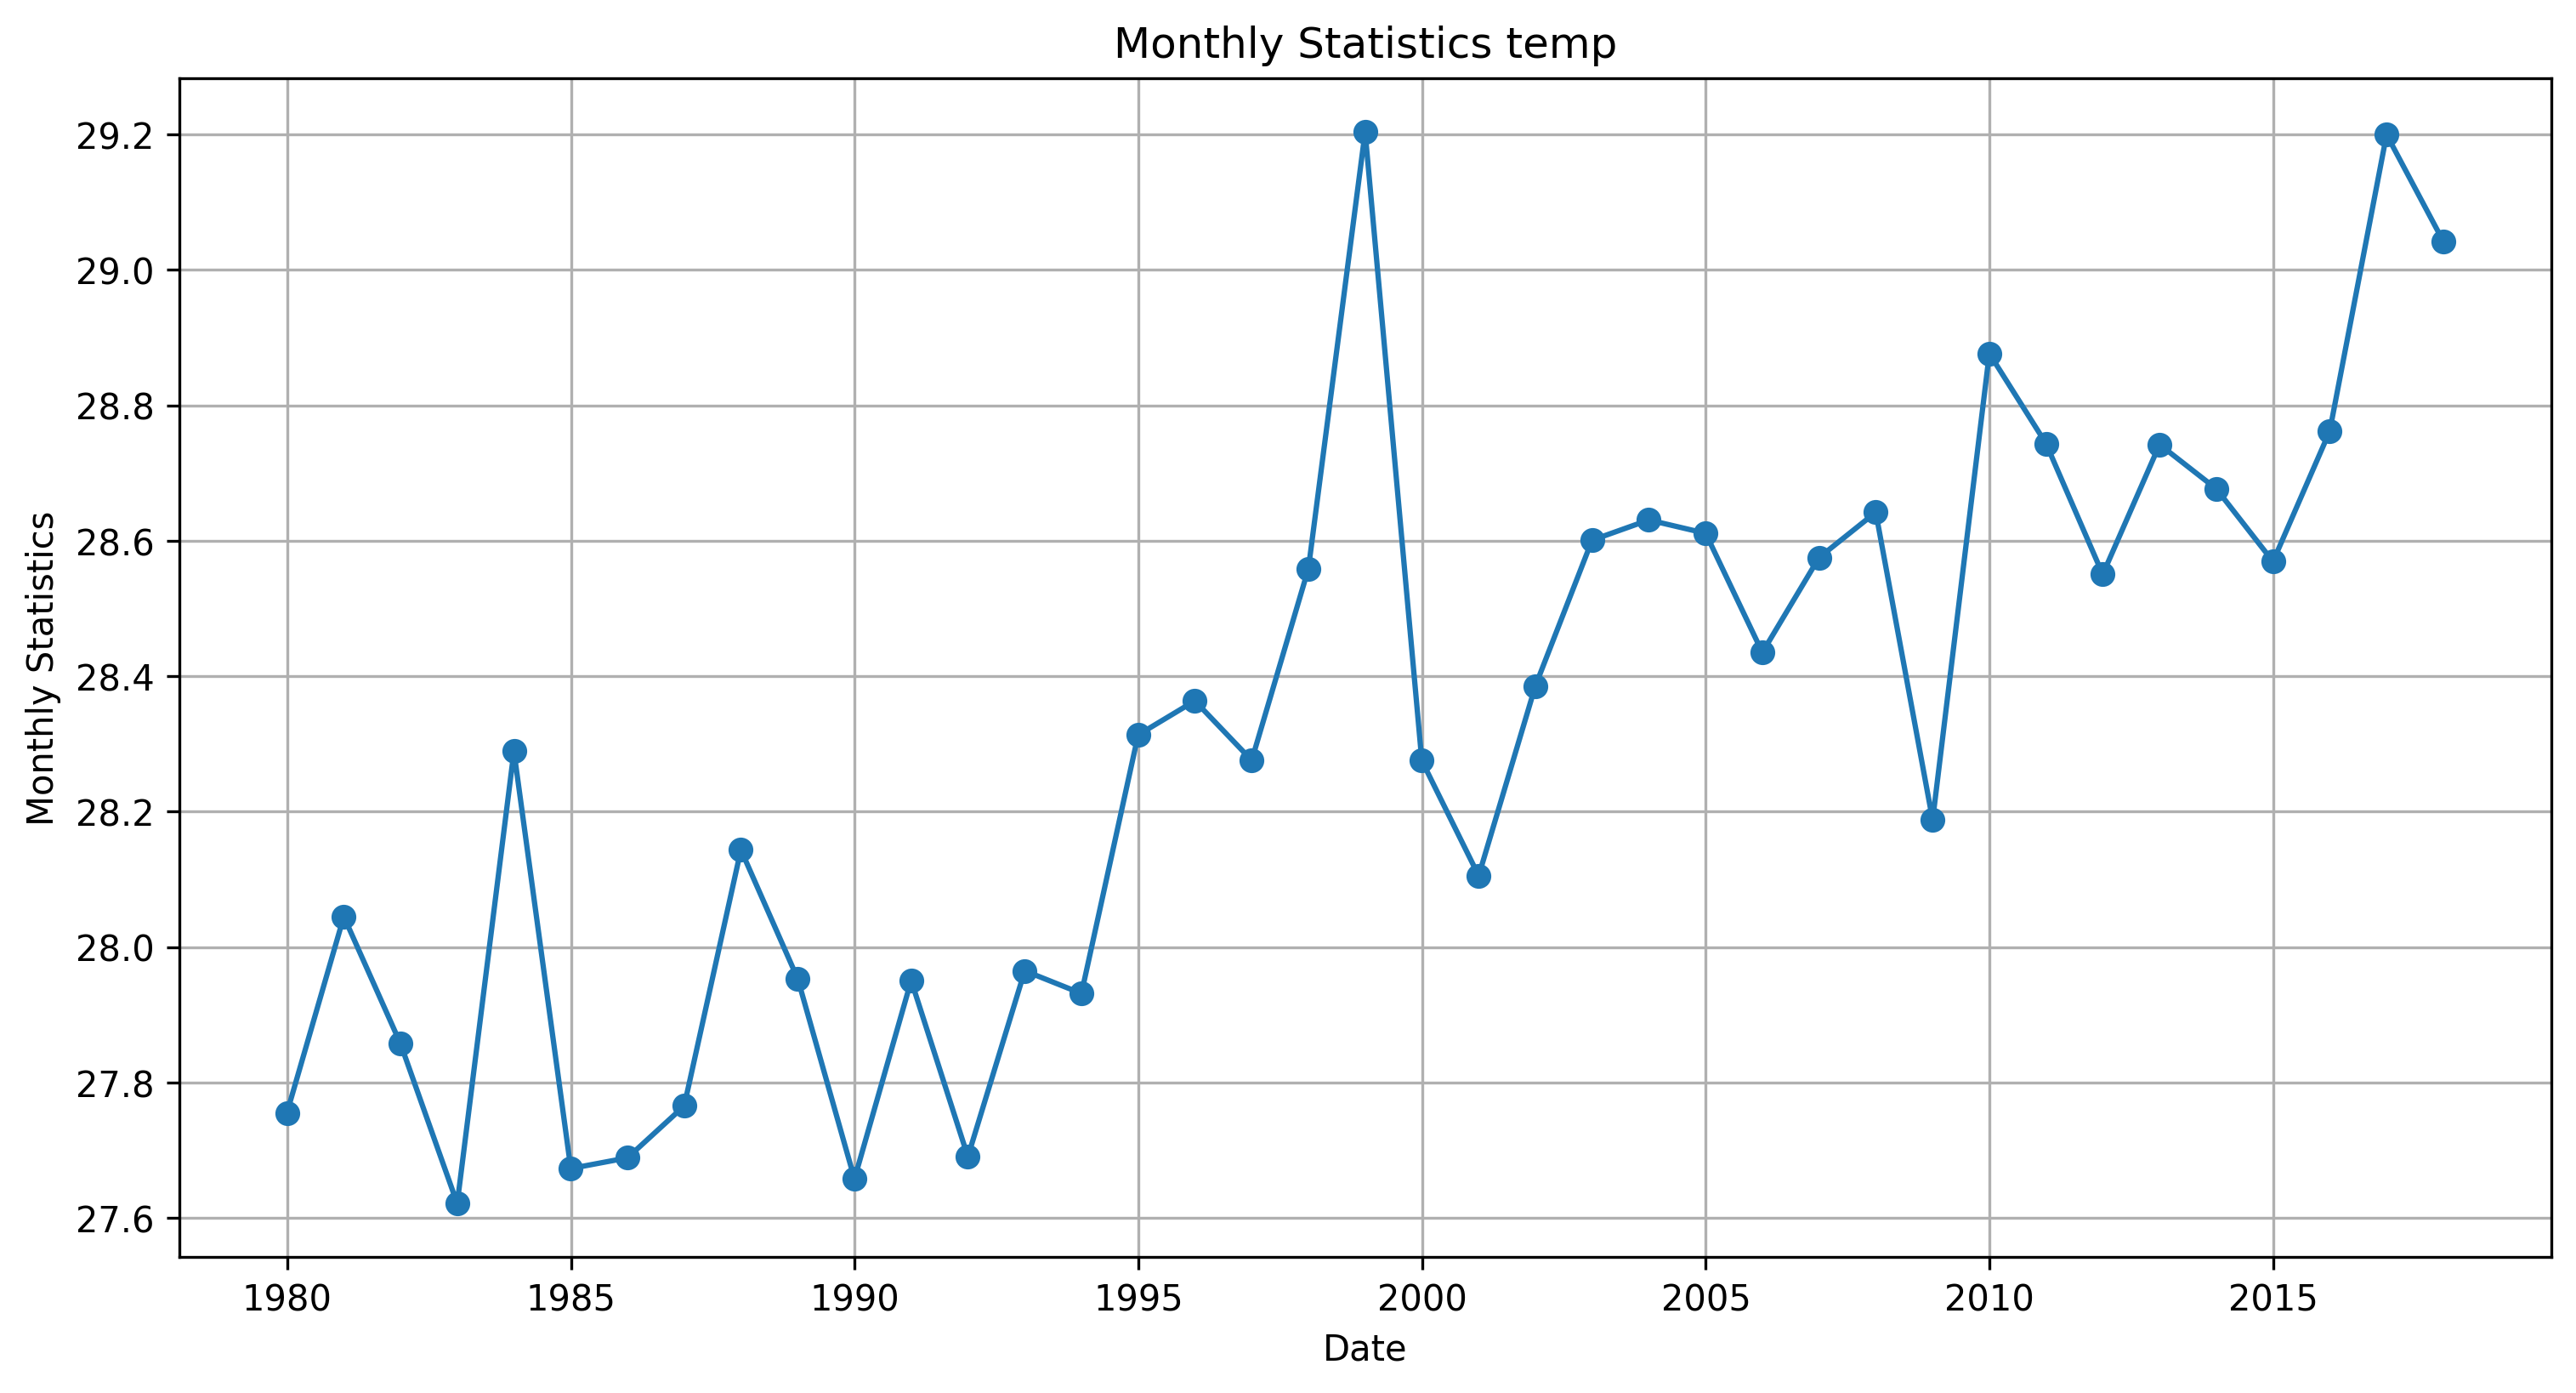

In [63]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_data.index, monthly_data['temp'], marker='o', linestyle='-')
plt.xlabel('Date')
plt.ylabel('Monthly Statistics')
plt.title('Monthly Statistics temp')
plt.grid(True)
plt.show()

In [60]:
# yearly data agg
yearly_data = train_df.set_index('datetime').resample('Y').agg({
    'rain_1h': 'mean', 
    'temp' : 'mean'
})

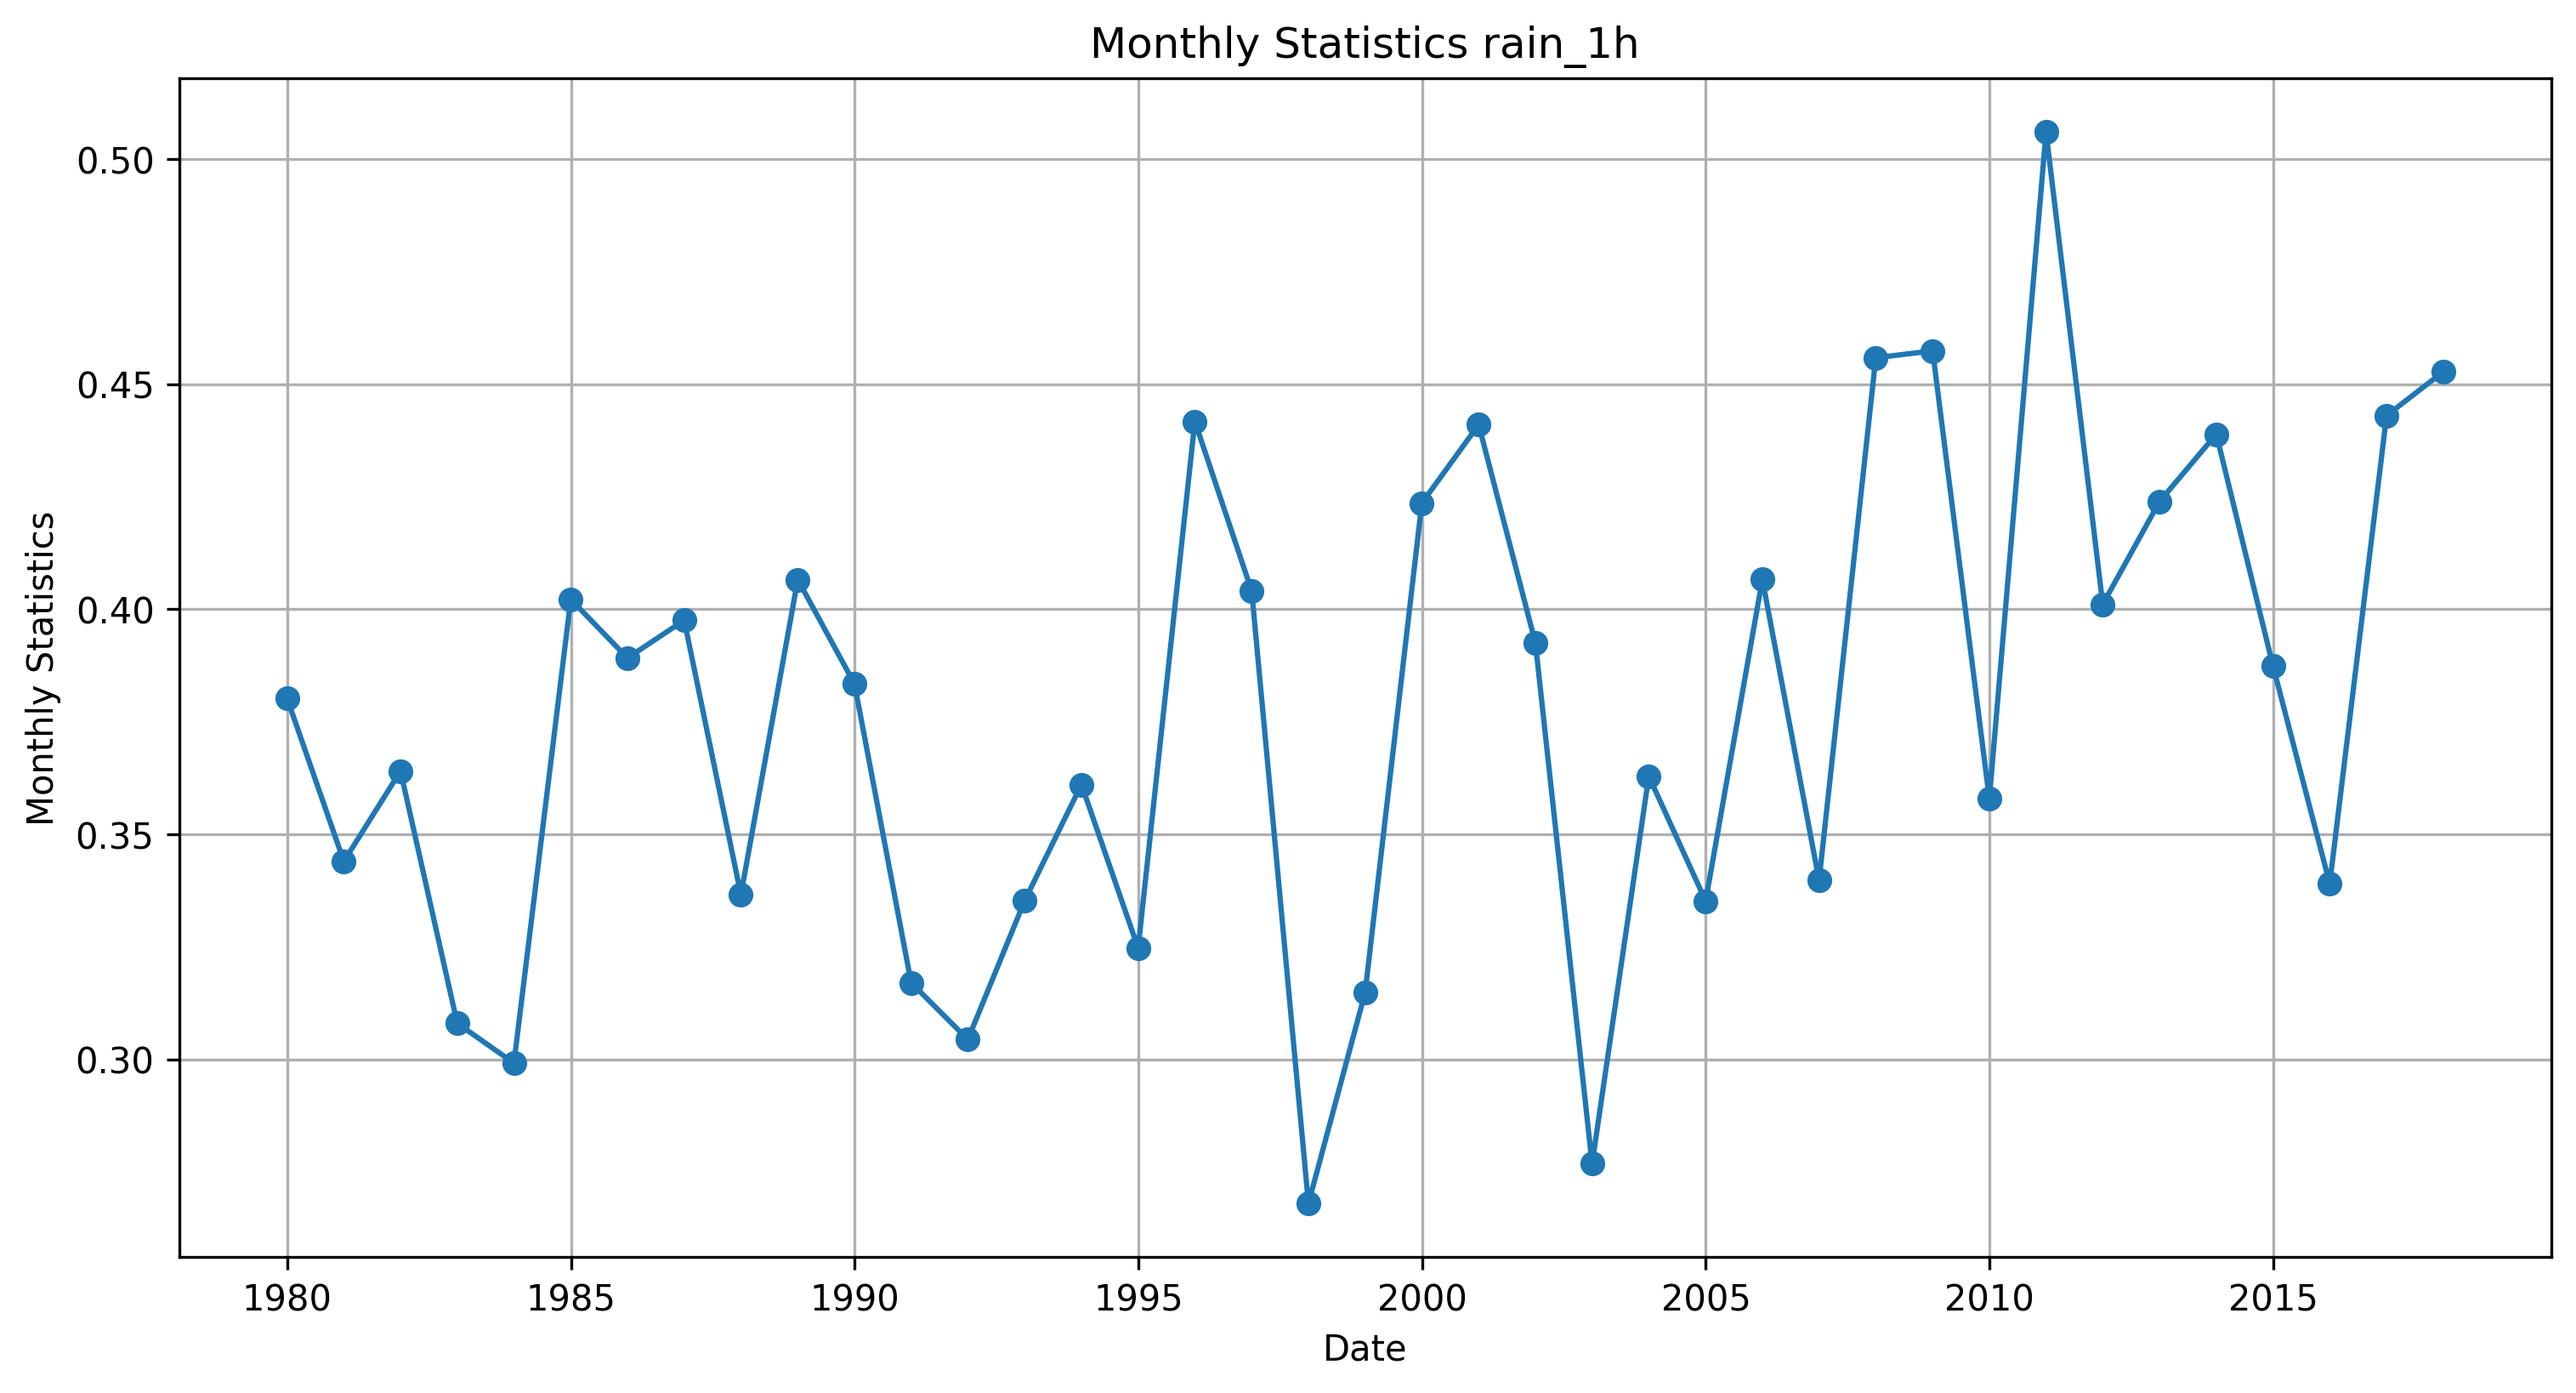

In [61]:
plt.figure(figsize=(12, 6))
plt.plot(yearly_data.index, yearly_data['rain_1h'], marker='o', linestyle='-')
plt.xlabel('Date')
plt.ylabel('Monthly Statistics')
plt.title('Monthly Statistics rain_1h')
plt.grid(True)
plt.show()

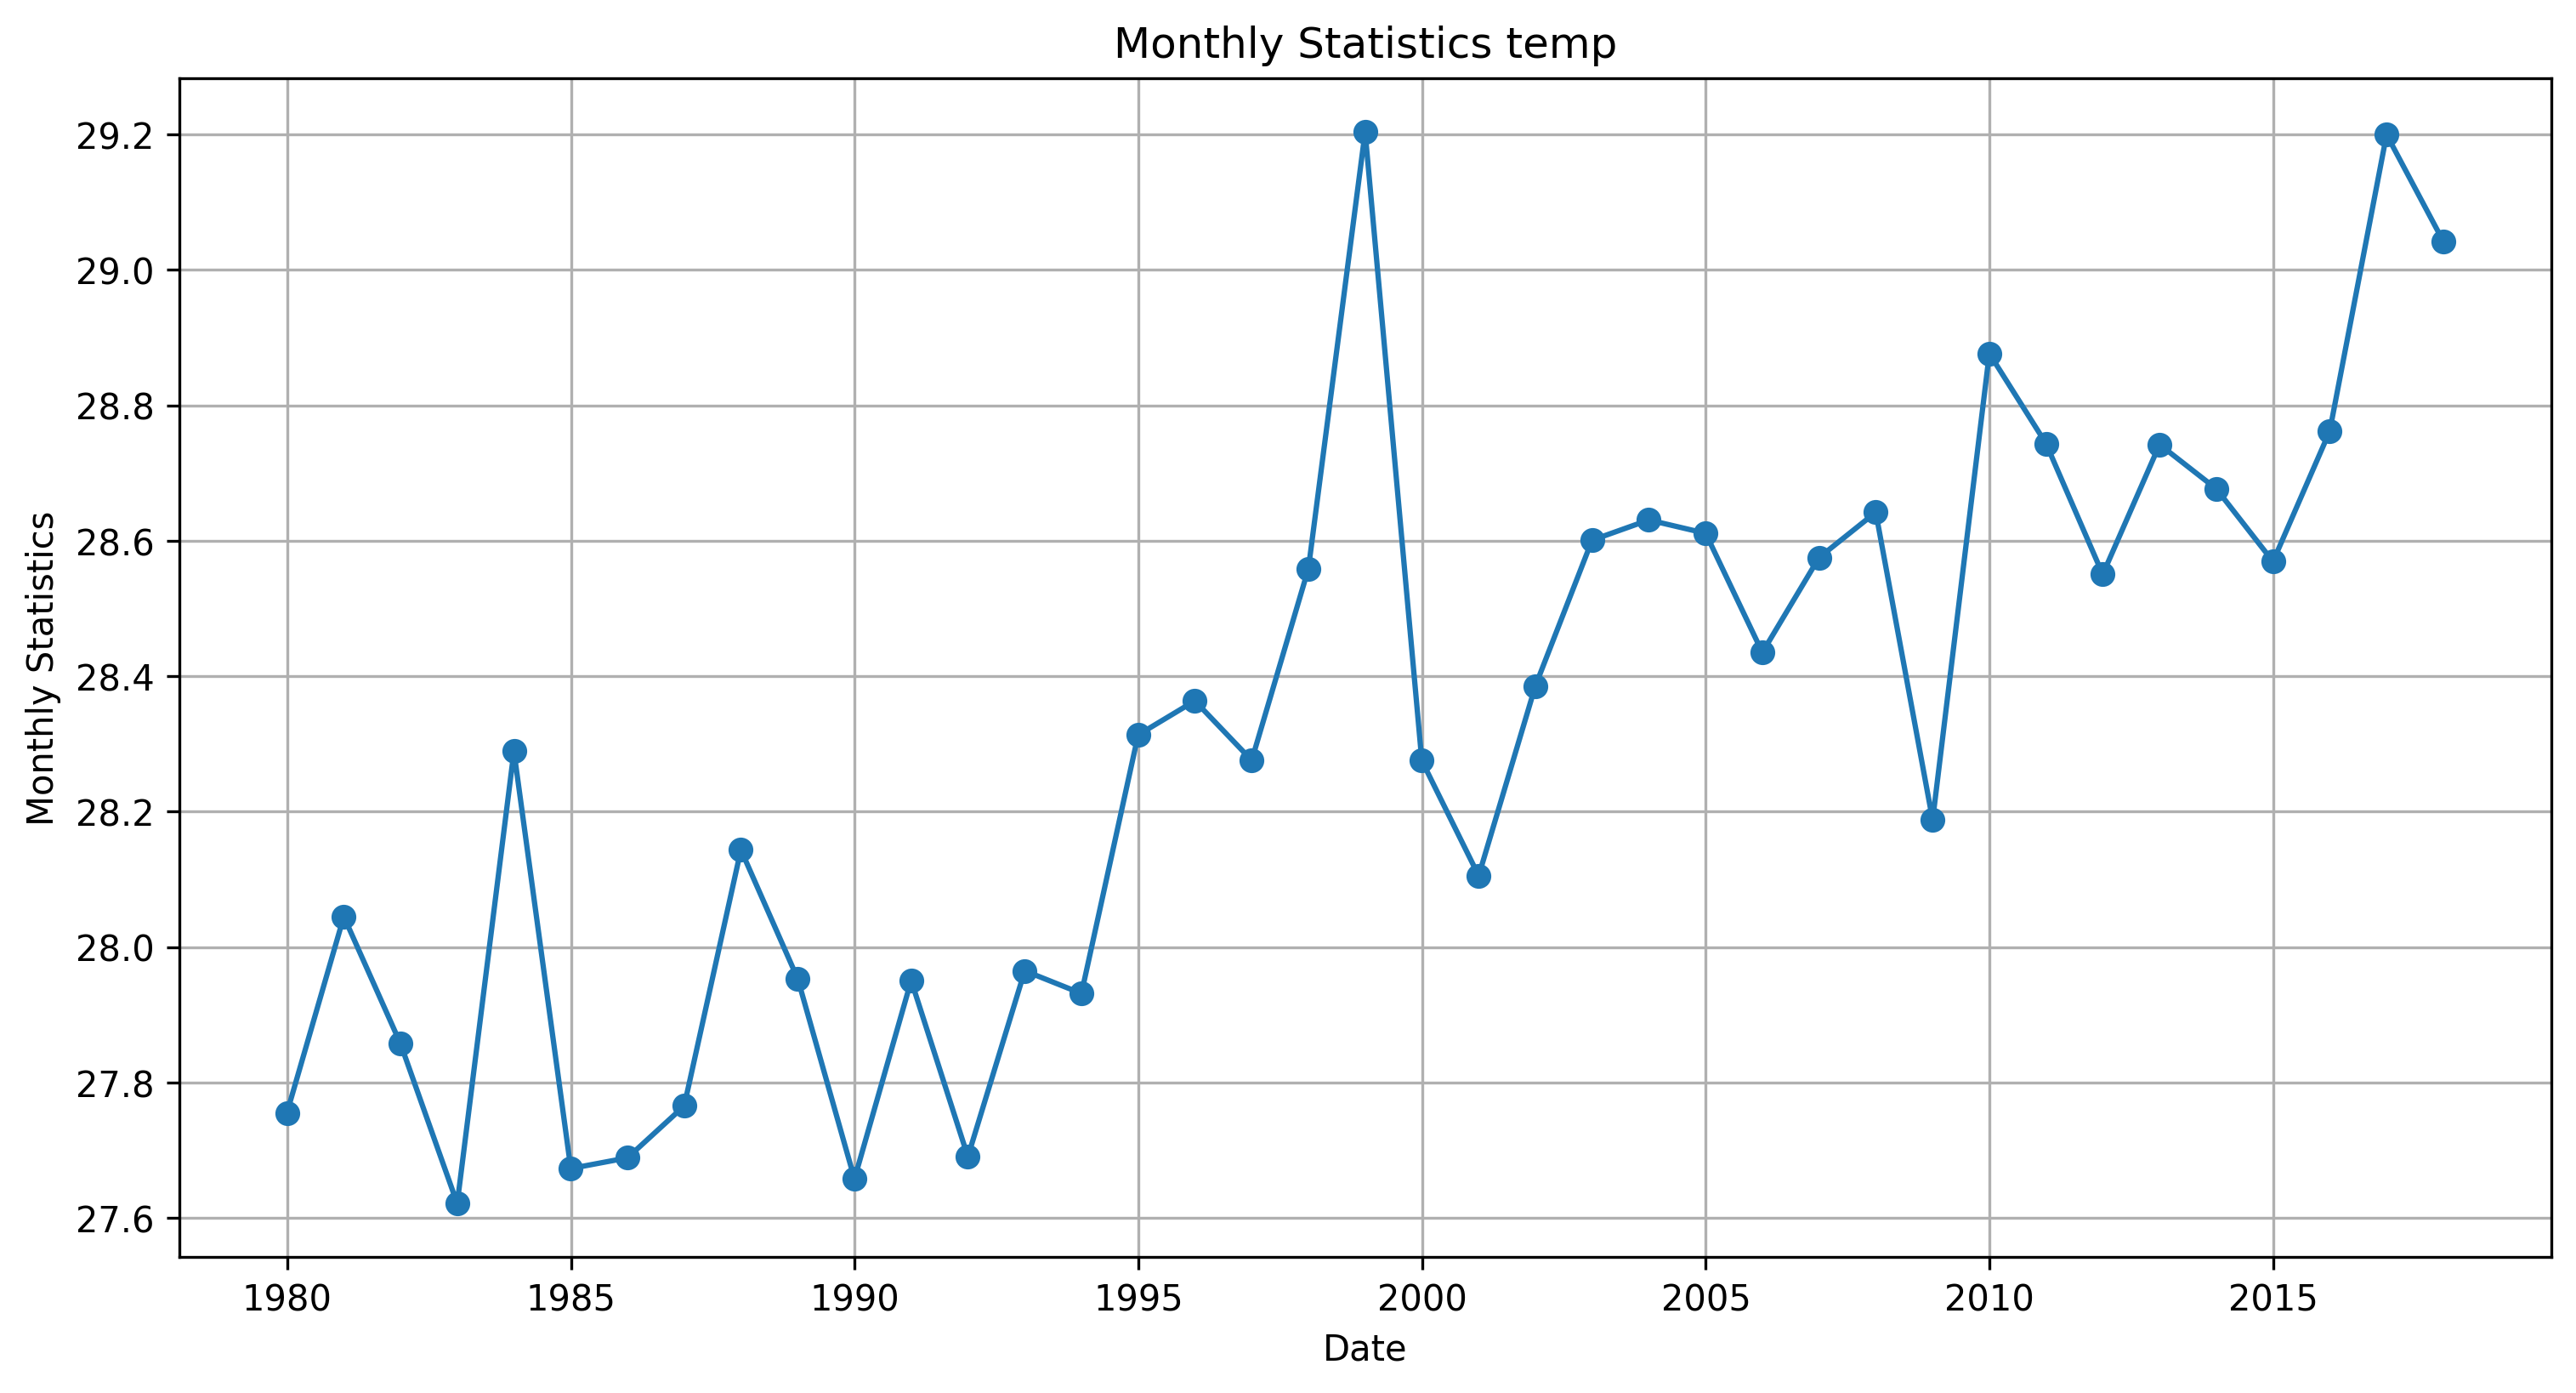

In [62]:
plt.figure(figsize=(12, 6))
plt.plot(yearly_data.index, yearly_data['temp'], marker='o', linestyle='-')
plt.xlabel('Date')
plt.ylabel('Monthly Statistics')
plt.title('Monthly Statistics temp')
plt.grid(True)
plt.show()

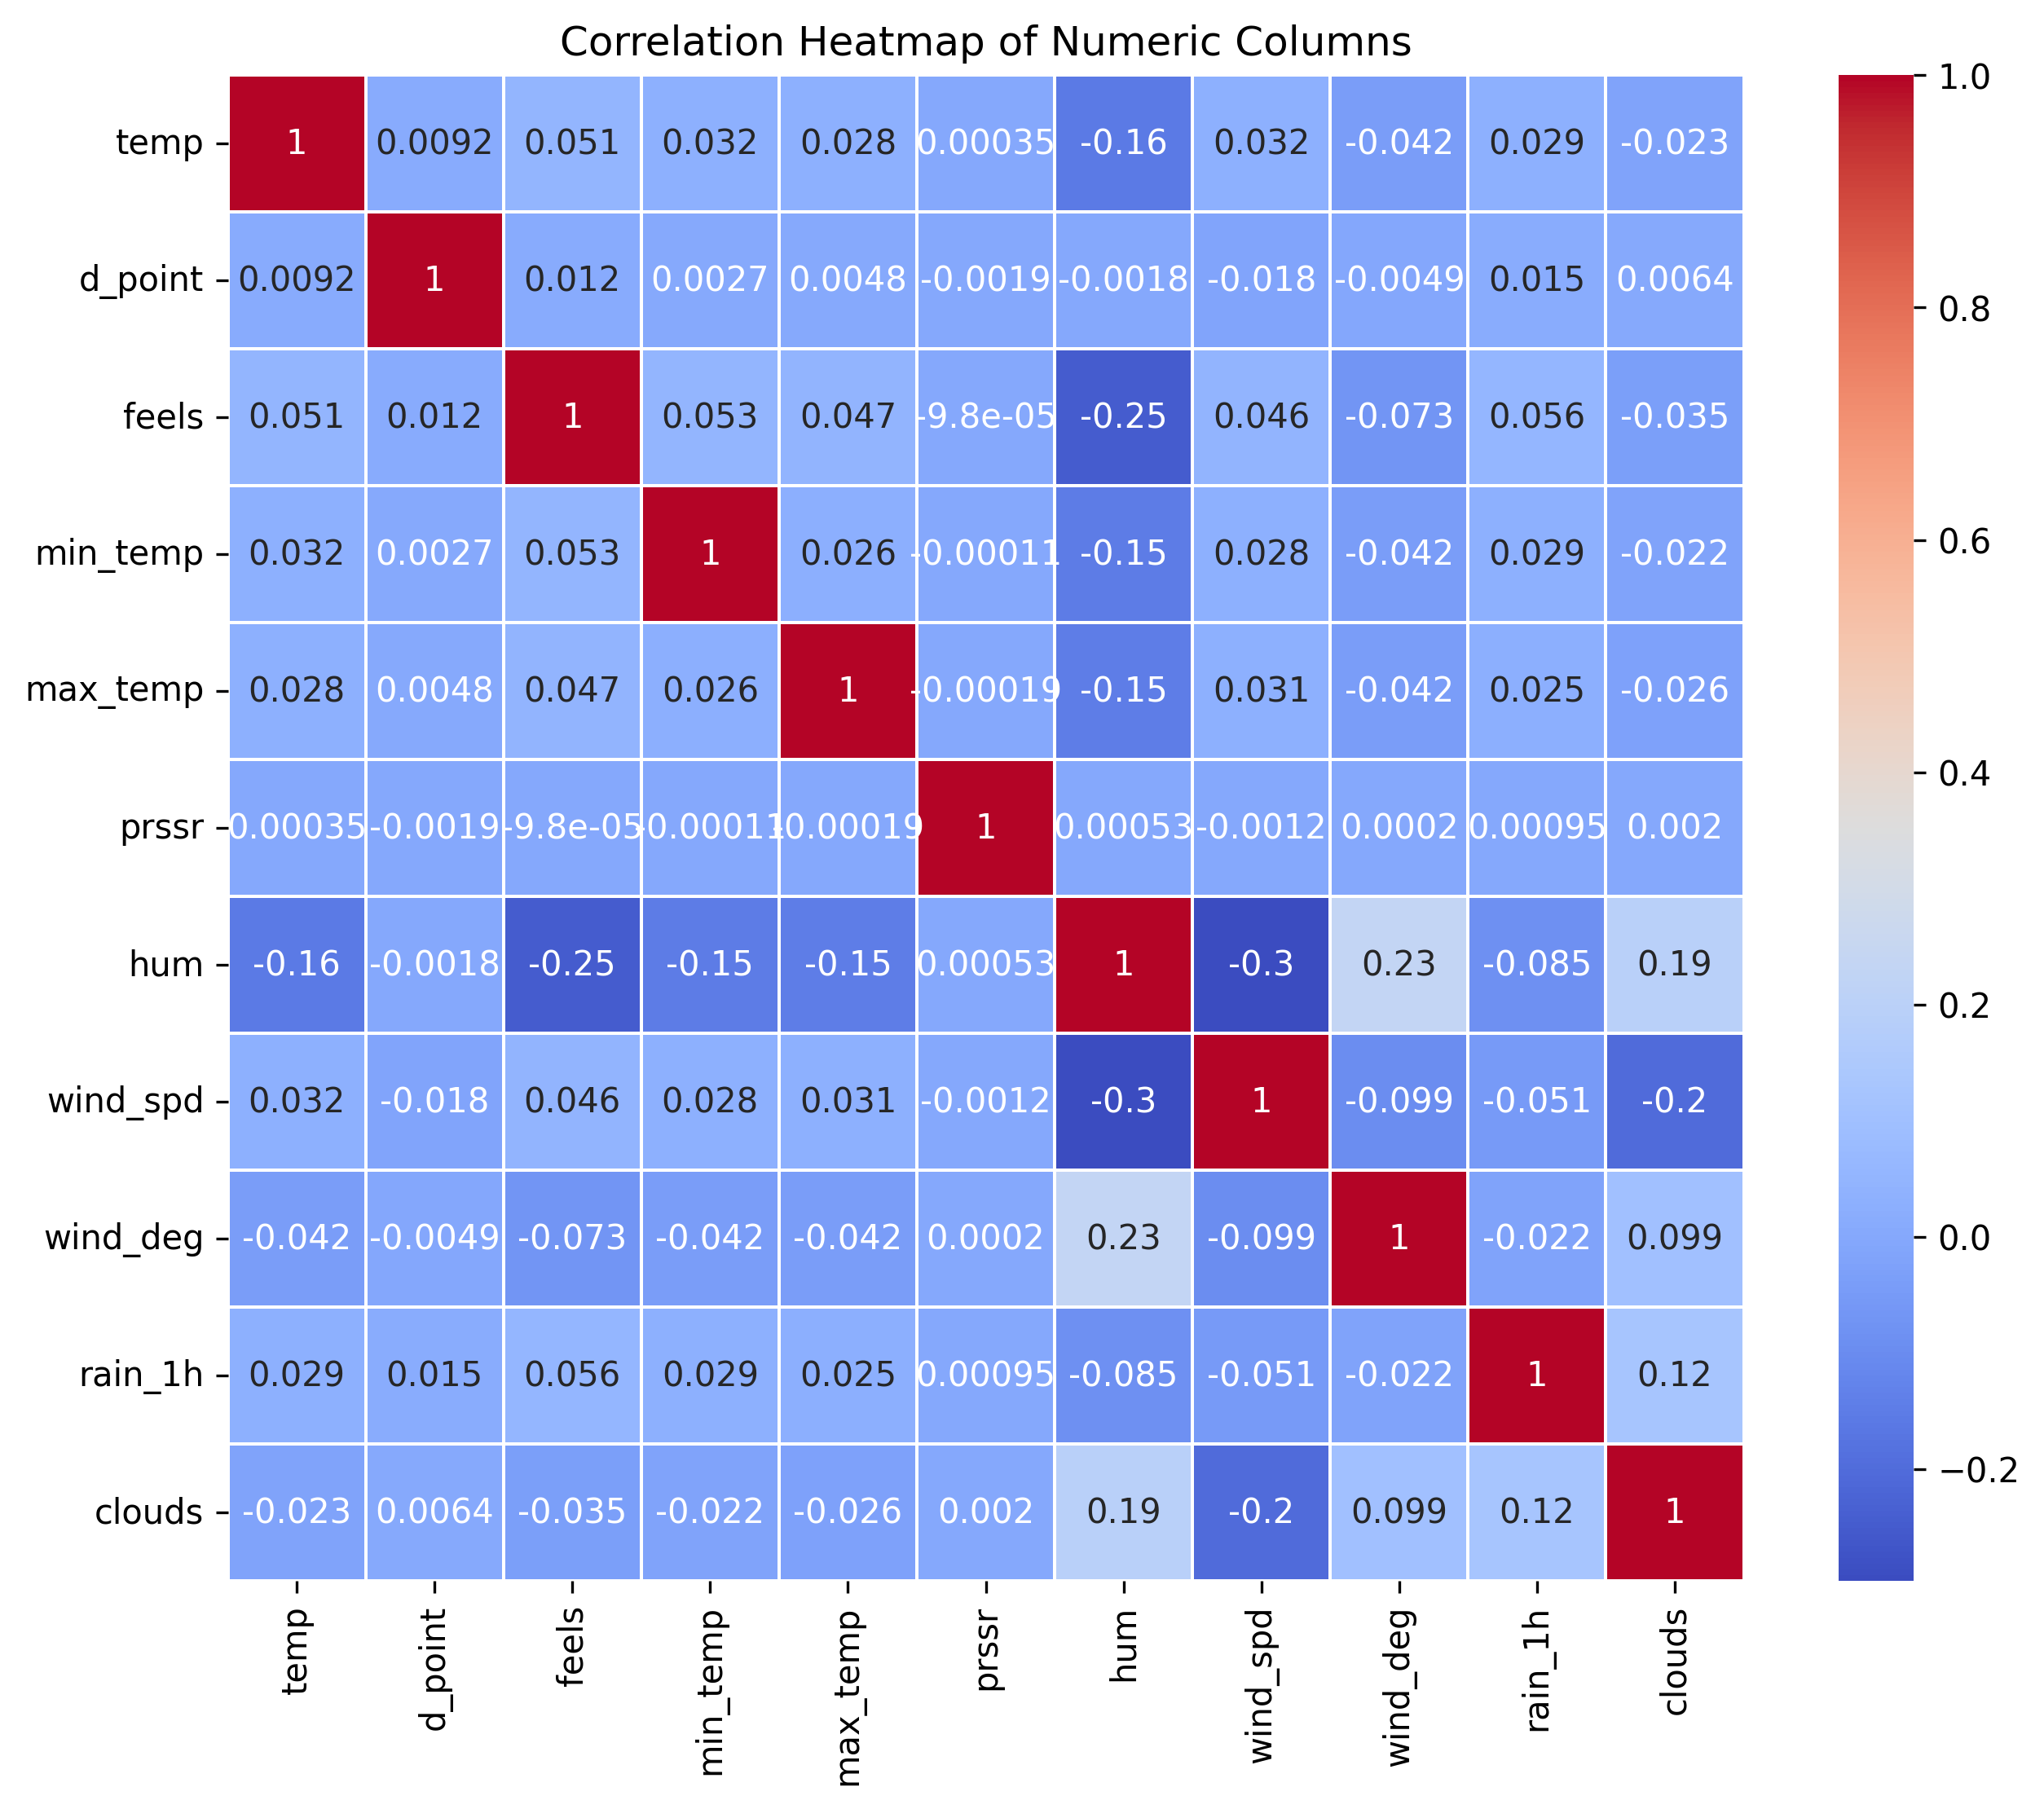

In [65]:
numeric_cols = train_df.select_dtypes(include=['number'])
corr_matrix = numeric_cols.corr()
plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=.5)

plt.title('Correlation Heatmap of Numeric Columns')

plt.show()

Beberapa fitur cukup berkorelasi tinggi seperti hum dengan feels, wind_spd dengan clouds. Tetapi tidak ada yang berkorelasi tinggi dengan rain_1h (target variabel kita)

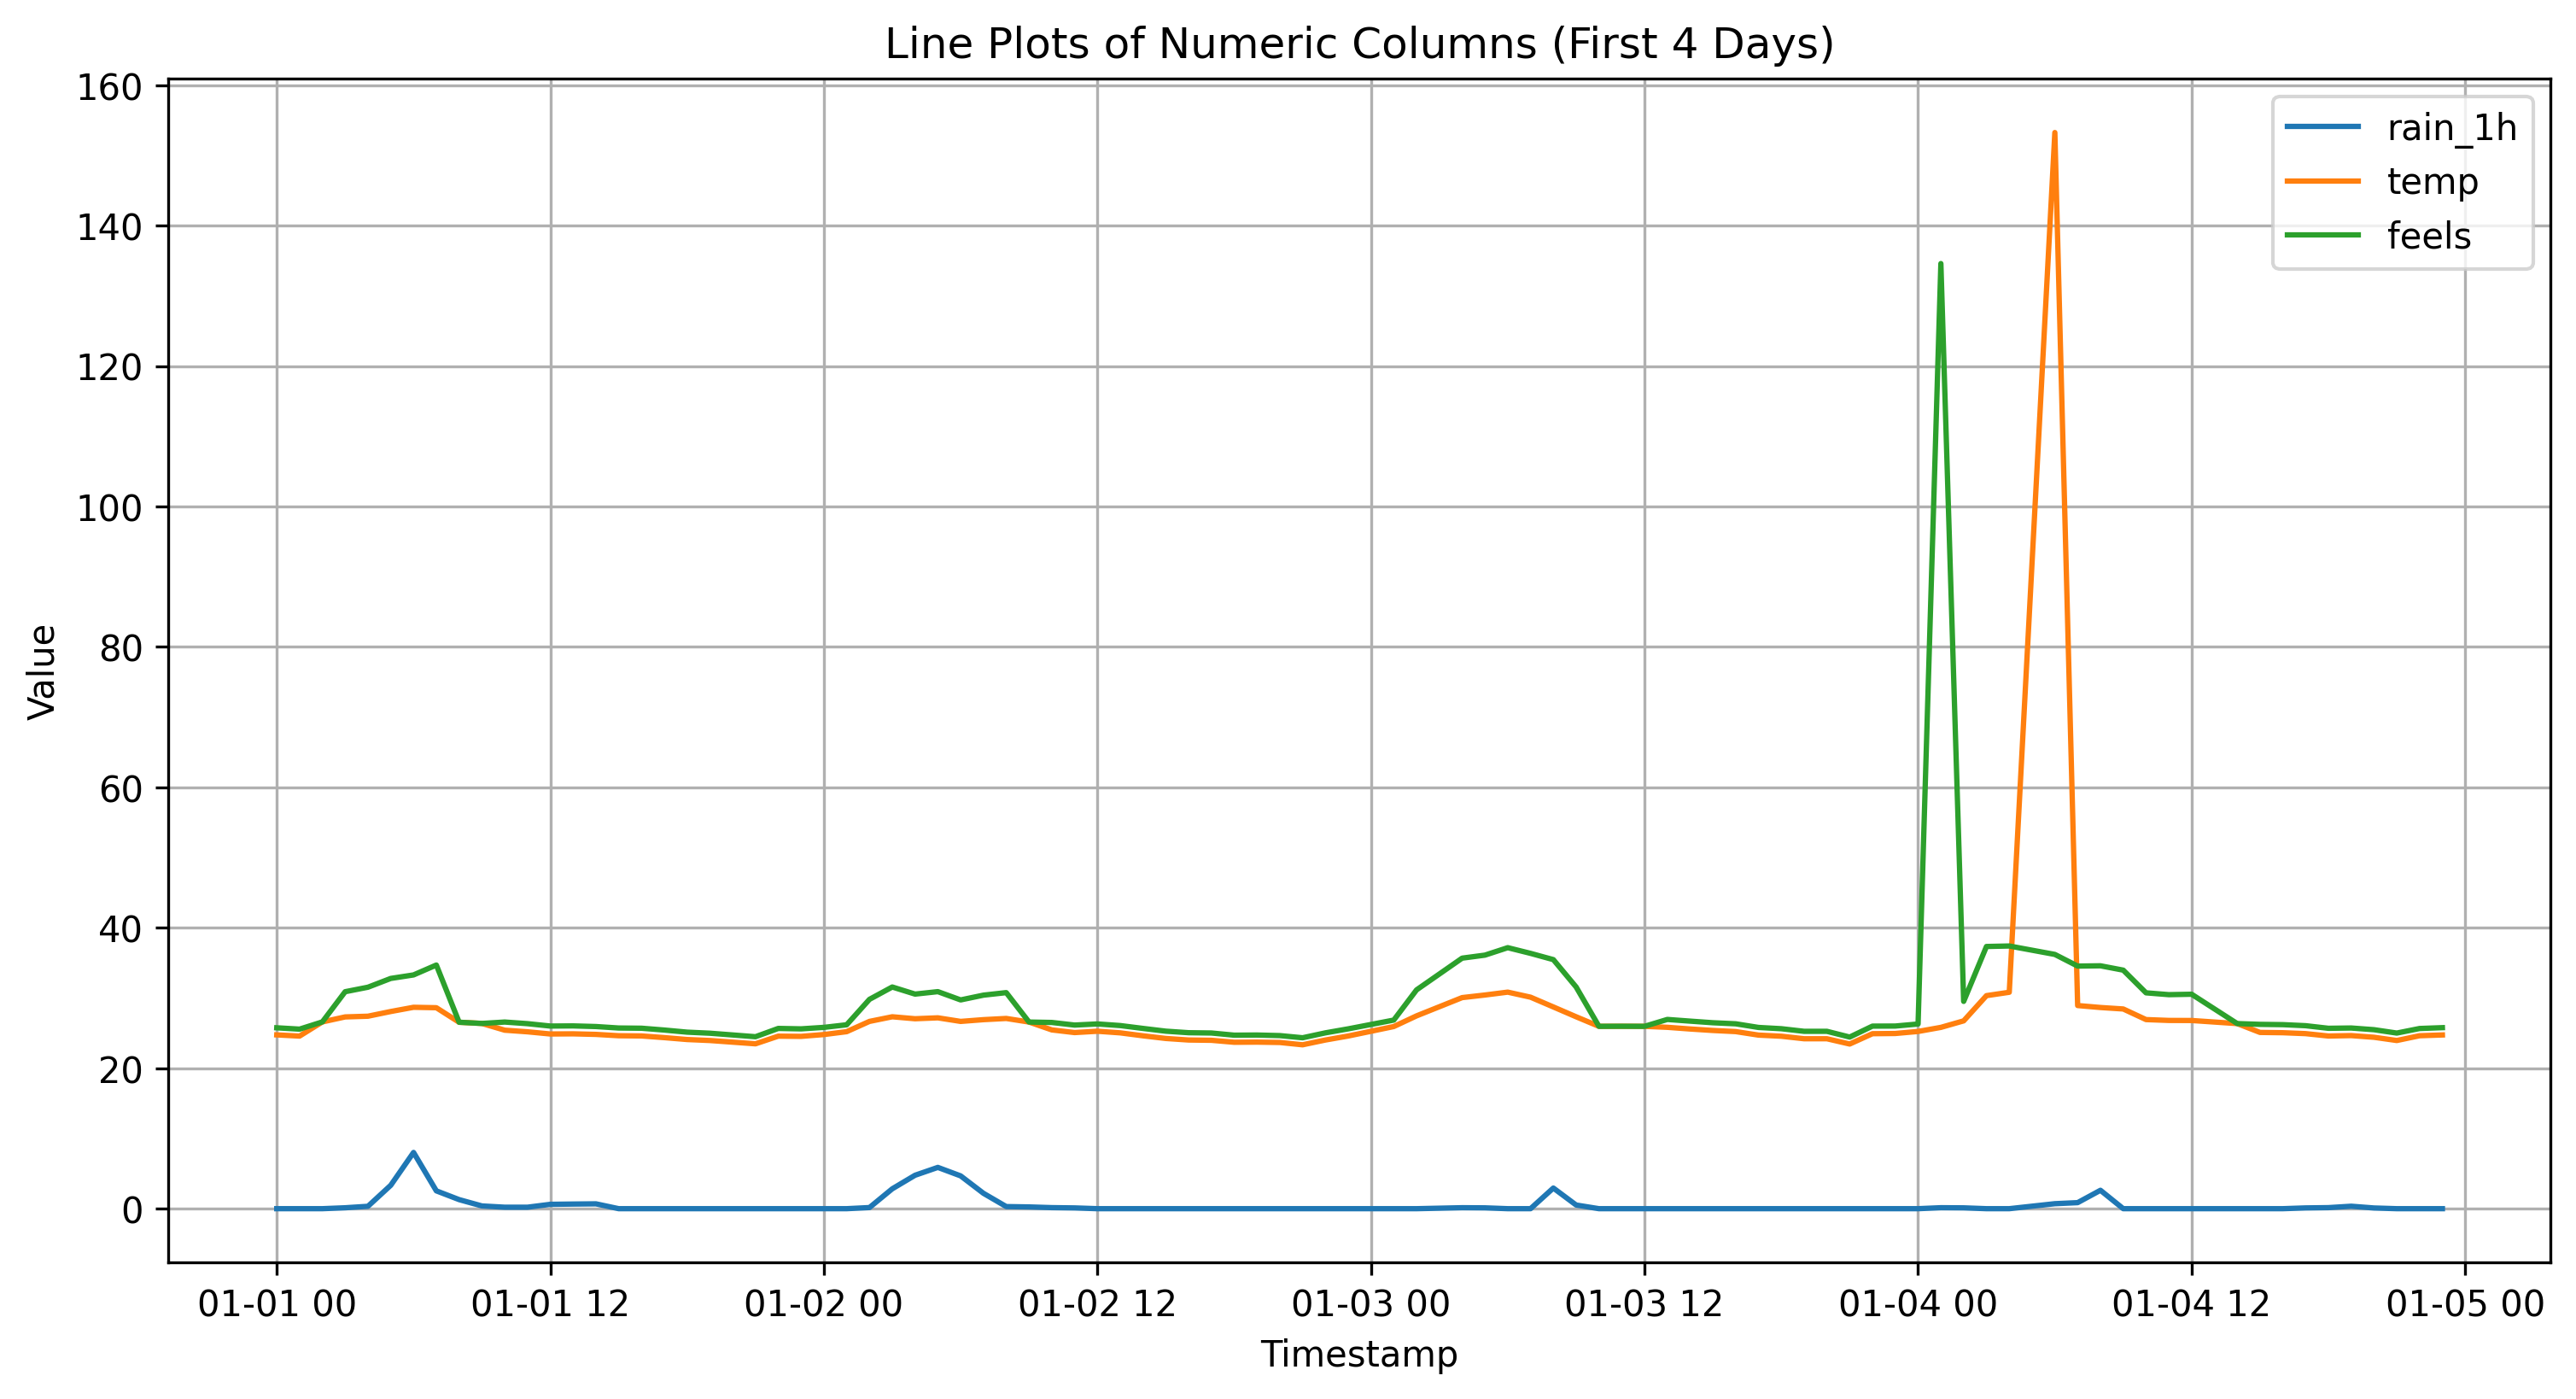

In [76]:
train_df['datetime'] = pd.to_datetime(train_df['datetime'])

# Subset the data for the first 4 days
start_date = train_df['datetime'].min()
end_date = start_date + pd.DateOffset(days=4)
subset_df = train_df[(train_df['datetime'] >= start_date) & (train_df['datetime'] < end_date)]
subset_df['datetime'] = pd.to_datetime(subset_df['datetime'])

# select cols that we want to viz
numeric_cols = subset_df[['rain_1h','temp','feels']]

# Set up the matplotlib figure
plt.figure(figsize=(12, 6))

# Iterate over each numeric column and create a line plot
for col in numeric_cols.columns:
    plt.plot(subset_df['datetime'], subset_df[col], label=col)

# Customize the plot
plt.xlabel('Datetime')
plt.ylabel('Value')
plt.title('Line Plots of some Numeric Columns (First 4 Days)')
plt.legend(loc='upper right')

# Show the plot
plt.grid(True)
plt.show()

Walaupun temp seharusnya dalam celcius, sepertinya ada beberapa yang dalam satuan suhu lain, dari plot diatas terlihat beberapa spike yang mencapai 130 dan 140 (tidak mungkin dalam celcius).